In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]     = 100
plt.rcParams["font.size"]      = 11
sns.set_theme(style="darkgrid")

os.makedirs("bluestock/reports/charts", exist_ok=True)

print("✅ All libraries imported")

✅ All libraries imported


In [2]:
PROC = "bluestock/data/processed"

df_fund  = pd.read_csv(f"{PROC}/01_fund_master_clean.csv")
df_nav   = pd.read_csv(f"{PROC}/02_nav_history_clean.csv",  parse_dates=["date"])
df_aum   = pd.read_csv(f"{PROC}/03_aum_clean.csv",          parse_dates=["date"])
df_sip   = pd.read_csv(f"{PROC}/04_sip_clean.csv",          parse_dates=["month"])
df_cat   = pd.read_csv(f"{PROC}/05_category_clean.csv",     parse_dates=["month"])
df_fol   = pd.read_csv(f"{PROC}/06_folio_clean.csv",        parse_dates=["month"])
df_perf  = pd.read_csv(f"{PROC}/07_performance_clean.csv")
df_txn   = pd.read_csv(f"{PROC}/08_transactions_clean.csv", parse_dates=["transaction_date"])
df_hold  = pd.read_csv(f"{PROC}/09_holdings_clean.csv")
df_bm    = pd.read_csv(f"{PROC}/10_benchmark_clean.csv",    parse_dates=["date"])

print(" All data loaded")
print(f"   NAV records      : {len(df_nav):,}")
print(f"   Transactions     : {len(df_txn):,}")
print(f"   Benchmark rows   : {len(df_bm):,}")
print(f"   Schemes          : {df_nav['amfi_code'].nunique()}")

 All data loaded
   NAV records      : 46,000
   Transactions     : 32,778
   Benchmark rows   : 8,050
   Schemes          : 40


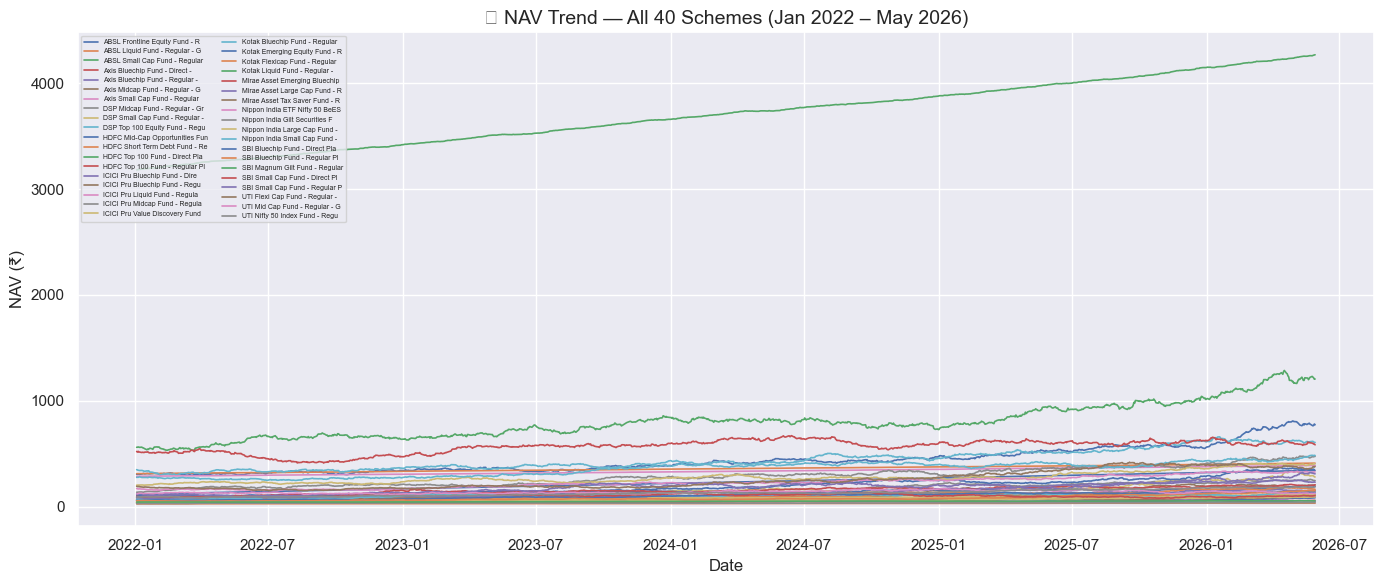

 Chart 1 saved — NAV Trends


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# Merge with fund names
nav_named = df_nav.merge(
    df_fund[["amfi_code","scheme_name","fund_house"]],
    on="amfi_code", how="left"
)
# Short label
nav_named["label"] = nav_named["scheme_name"].str[:30]

for label, grp in nav_named.groupby("label"):
    ax.plot(grp["date"], grp["nav"], linewidth=1.2, label=label)

ax.set_title("📈 NAV Trend — All 40 Schemes (Jan 2022 – May 2026)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("NAV (₹)")
ax.legend(fontsize=5, loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig("bluestock/reports/charts/01_nav_trends.png", dpi=150)
plt.show()
print(" Chart 1 saved — NAV Trends")

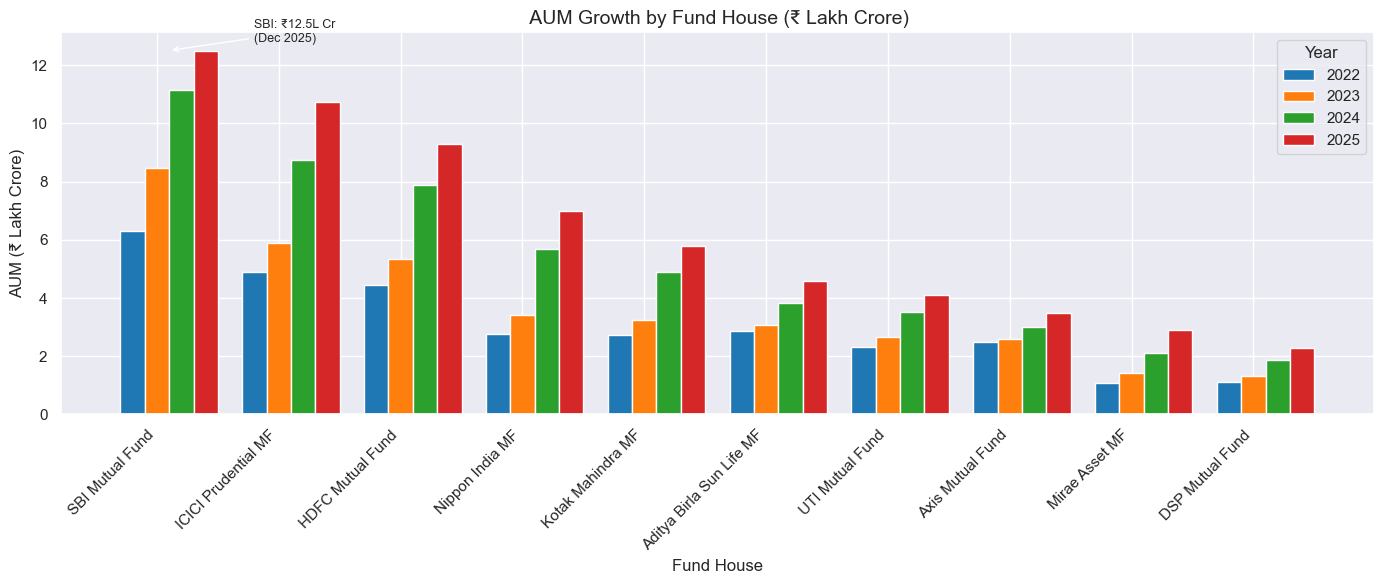

 Chart 2 saved — AUM Growth


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot for grouped bar
aum_pivot = df_aum.pivot_table(
    index="fund_house",
    columns=df_aum["date"].dt.year,
    values="aum_lakh_crore",
    aggfunc="max"
)
aum_pivot = aum_pivot.sort_values(aum_pivot.columns[-1], ascending=False)

x     = np.arange(len(aum_pivot))
width = 0.2
cols  = aum_pivot.columns.tolist()
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

for i, (yr, col) in enumerate(zip(cols, colors)):
    ax.bar(x + i*width, aum_pivot[yr], width, label=str(yr), color=col)

ax.set_title(" AUM Growth by Fund House (₹ Lakh Crore)", fontsize=14)
ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (₹ Lakh Crore)")
ax.set_xticks(x + width)
ax.set_xticklabels(aum_pivot.index, rotation=45, ha="right")
ax.legend(title="Year")
# Highlight SBI
ax.annotate("SBI: ₹12.5L Cr\n(Dec 2025)",
            xy=(0 + 1.5*width, aum_pivot.iloc[0, -1]),
            xytext=(1, aum_pivot.iloc[0,-1] + 0.3),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
plt.tight_layout()
plt.savefig("bluestock/reports/charts/02_aum_growth.png", dpi=150)
plt.show()
print(" Chart 2 saved — AUM Growth")

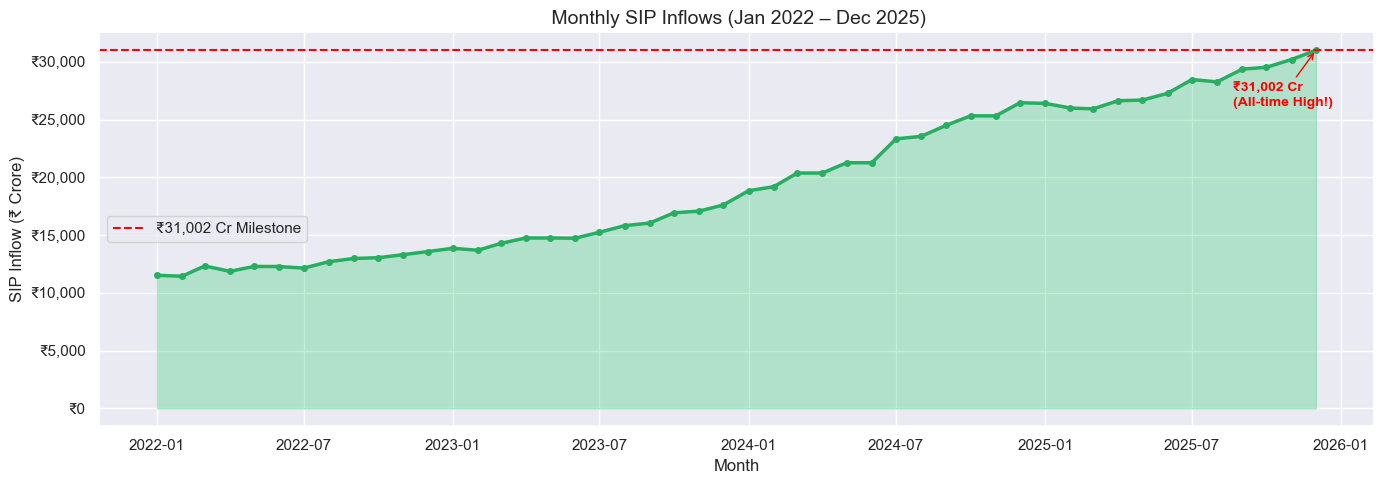

 Chart 3 saved — SIP Inflows


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_sip["month"], df_sip["sip_inflow_crore"],
                alpha=0.3, color="#2ecc71")
ax.plot(df_sip["month"], df_sip["sip_inflow_crore"],
        color="#27ae60", linewidth=2.5, marker="o", markersize=4)

# Milestone
peak_row = df_sip.loc[df_sip["sip_inflow_crore"].idxmax()]
ax.annotate(f"₹{peak_row['sip_inflow_crore']:,} Cr\n(All-time High!)",
            xy=(peak_row["month"], peak_row["sip_inflow_crore"]),
            xytext=(-60, -40), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10, color="red", fontweight="bold")

ax.axhline(y=31002, color="red", linestyle="--",
           linewidth=1.5, label="₹31,002 Cr Milestone")

ax.set_title(" Monthly SIP Inflows (Jan 2022 – Dec 2025)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("SIP Inflow (₹ Crore)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"₹{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("bluestock/reports/charts/03_sip_inflows.png", dpi=150)
plt.show()
print(" Chart 3 saved — SIP Inflows")

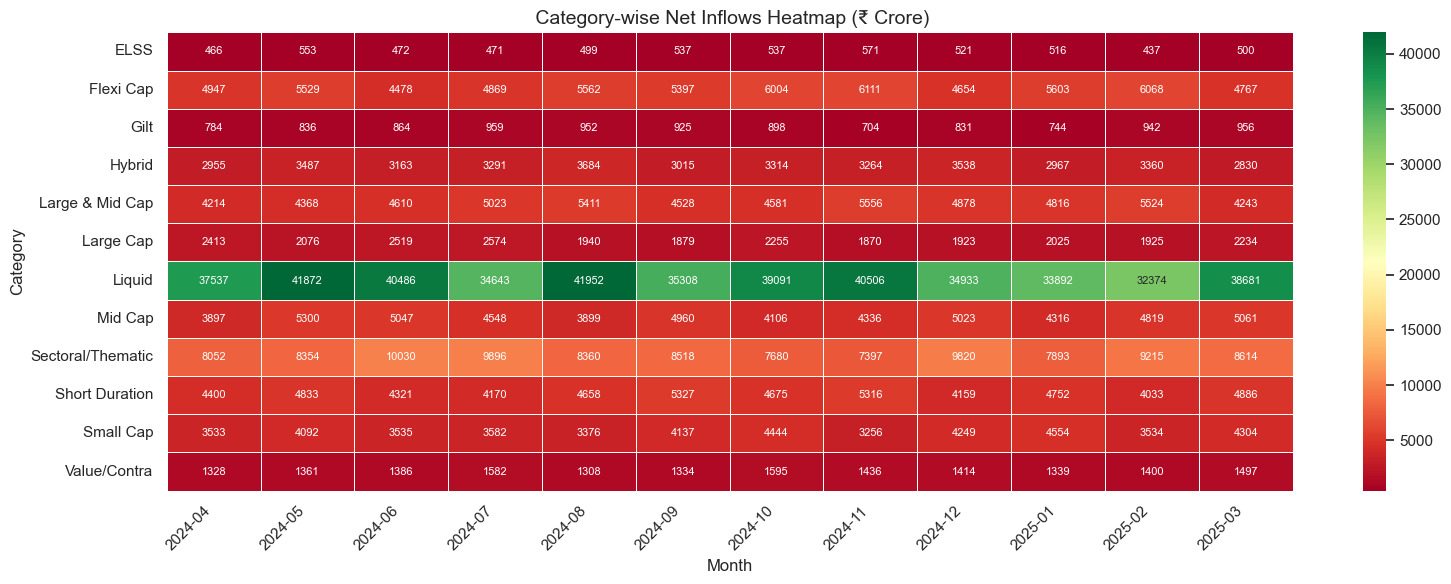

 Chart 4 saved — Category Heatmap


In [9]:
pivot = df_cat.pivot_table(
    index="category",
    columns=df_cat["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore",
    aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, annot=True, fmt=".0f",
            cmap="RdYlGn", ax=ax,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 8})
ax.set_title(" Category-wise Net Inflows Heatmap (₹ Crore)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("bluestock/reports/charts/04_category_heatmap.png", dpi=150)
plt.show()
print(" Chart 4 saved — Category Heatmap")

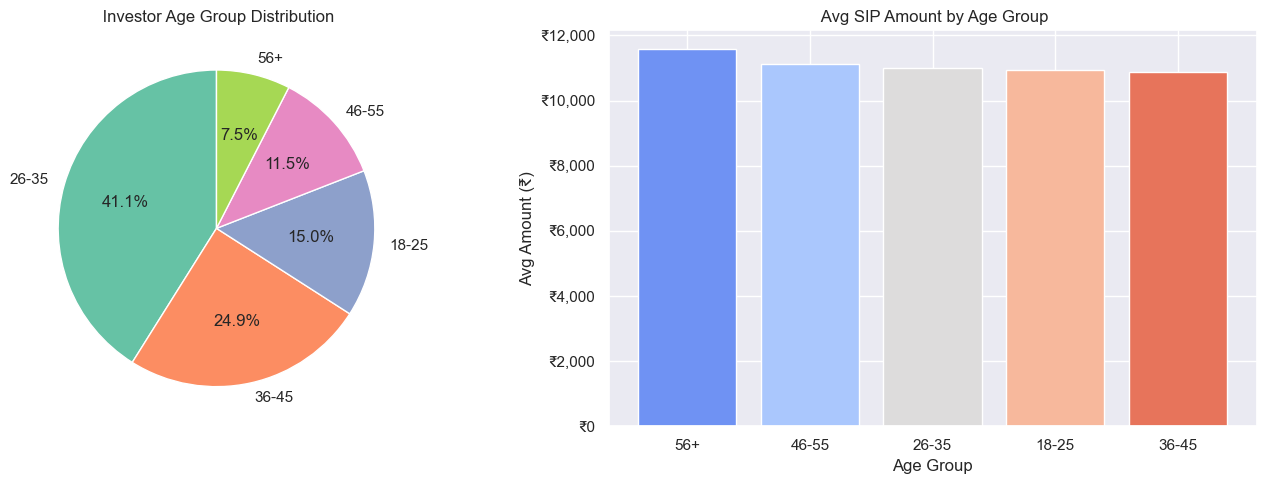

 Charts 5 & 6 saved — Demographics


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 5 — Age Group Distribution
age_counts = df_txn["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index,
            autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("Set2", len(age_counts)))
axes[0].set_title(" Investor Age Group Distribution")

# Chart 6 — SIP Amount by Age Group
sip_age = df_txn[df_txn["transaction_type"] == "Sip"].groupby(
    "age_group")["amount_inr"].mean().sort_values(ascending=False)
axes[1].bar(sip_age.index, sip_age.values,
            color=sns.color_palette("coolwarm", len(sip_age)))
axes[1].set_title(" Avg SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Avg Amount (₹)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"₹{x:,.0f}"))

plt.tight_layout()
plt.savefig("bluestock/reports/charts/05_06_demographics.png", dpi=150)
plt.show()
print(" Charts 5 & 6 saved — Demographics")

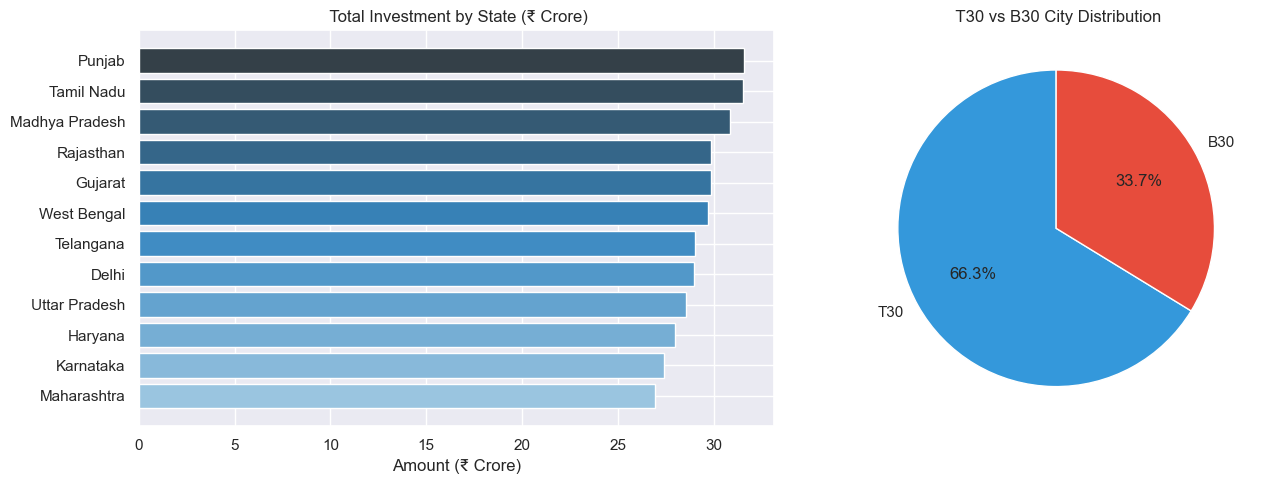

 Charts 7 & 8 saved — Geography


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 7 — SIP by State
state_amt = df_txn.groupby("state")["amount_inr"].sum().sort_values(ascending=True)
axes[0].barh(state_amt.index, state_amt.values / 1e7,
             color=sns.color_palette("Blues_d", len(state_amt)))
axes[0].set_title(" Total Investment by State (₹ Crore)")
axes[0].set_xlabel("Amount (₹ Crore)")

# Chart 8 — T30 vs B30
tier_counts = df_txn["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index,
            autopct="%1.1f%%", startangle=90,
            colors=["#3498db","#e74c3c"])
axes[1].set_title(" T30 vs B30 City Distribution")

plt.tight_layout()
plt.savefig("bluestock/reports/charts/07_08_geography.png", dpi=150)
plt.show()
print(" Charts 7 & 8 saved — Geography")

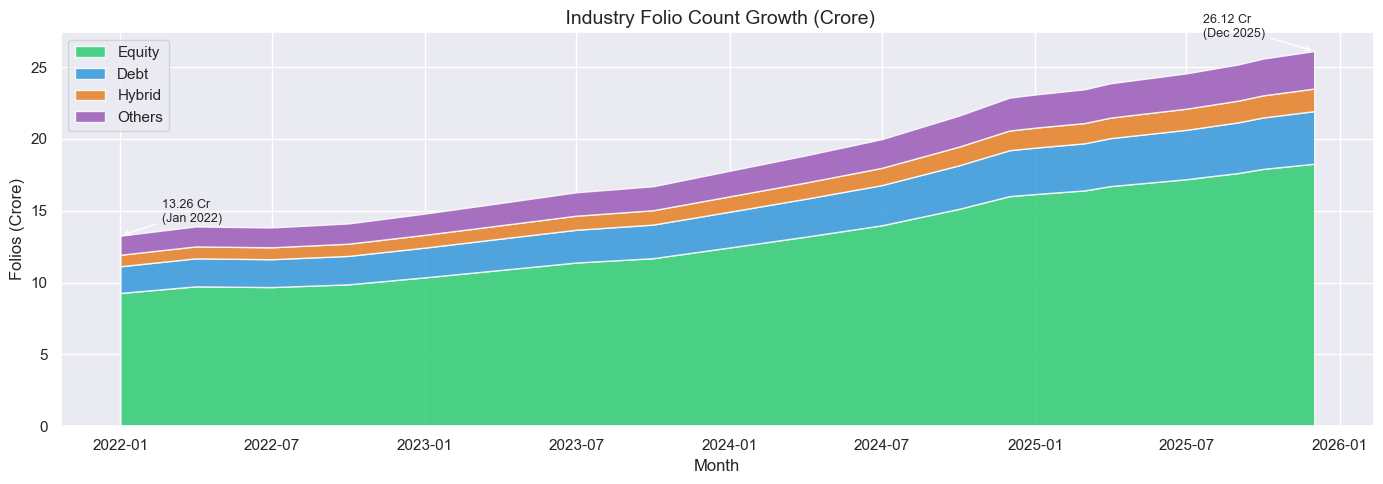

 Chart 9 saved — Folio Growth


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.stackplot(
    df_fol["month"],
    df_fol["equity_folios_crore"],
    df_fol["debt_folios_crore"],
    df_fol["hybrid_folios_crore"],
    df_fol["others_folios_crore"],
    labels=["Equity","Debt","Hybrid","Others"],
    colors=["#2ecc71","#3498db","#e67e22","#9b59b6"],
    alpha=0.85
)
# Annotate milestones
ax.annotate("13.26 Cr\n(Jan 2022)",
            xy=(df_fol["month"].iloc[0], df_fol["total_folios_crore"].iloc[0]),
            xytext=(30, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("26.12 Cr\n(Dec 2025)",
            xy=(df_fol["month"].iloc[-1], df_fol["total_folios_crore"].iloc[-1]),
            xytext=(-80, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title(" Industry Folio Count Growth (Crore)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Folios (Crore)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("bluestock/reports/charts/09_folio_growth.png", dpi=150)
plt.show()
print(" Chart 9 saved — Folio Growth")

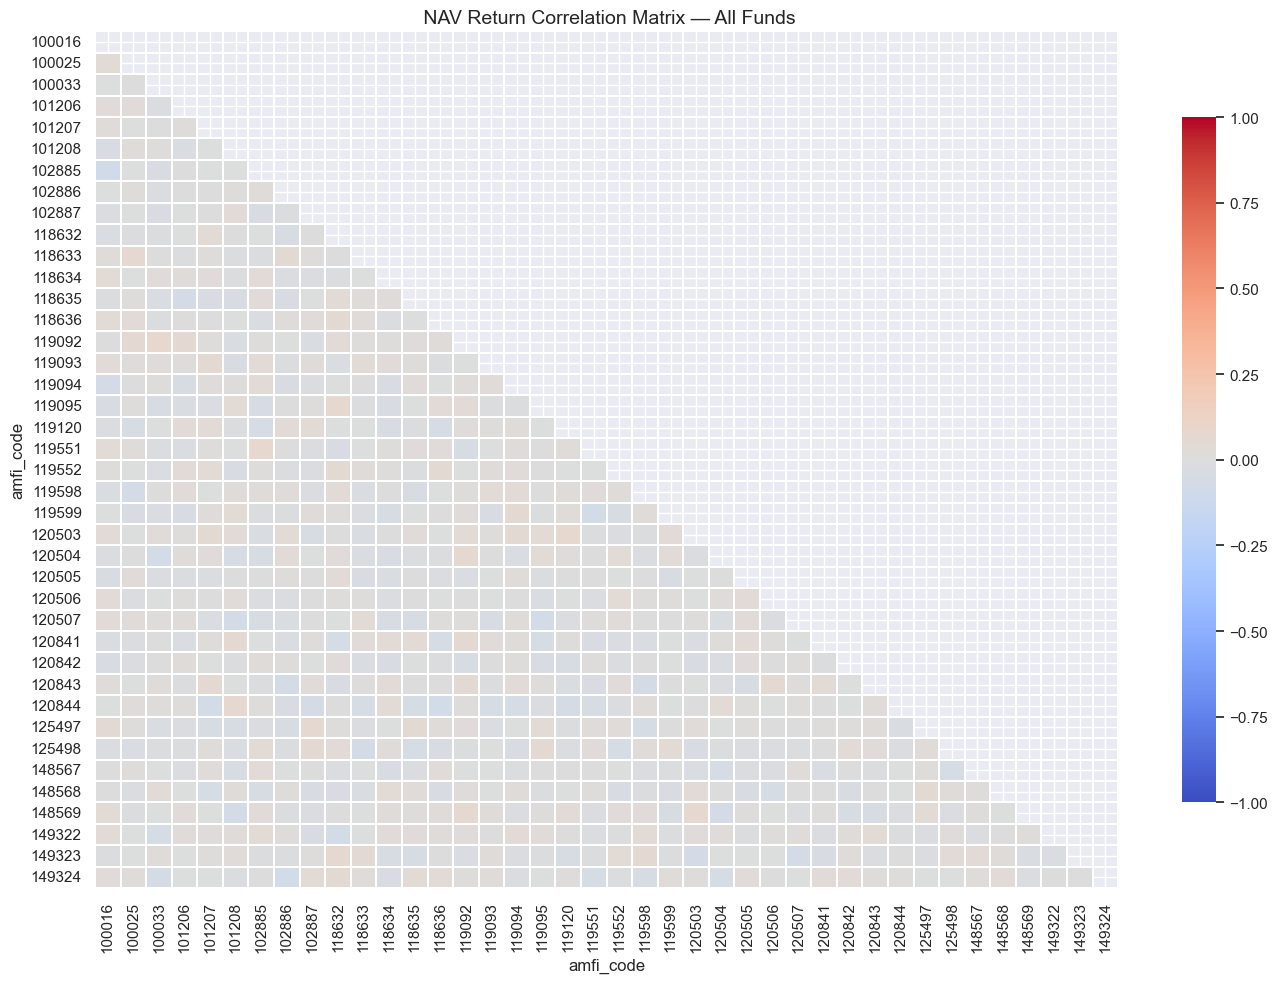

 Chart 10 saved — Correlation Matrix


In [13]:
# Pivot NAV returns wide — one column per fund
nav_pivot = df_nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return_pct"
).dropna(axis=1, thresh=200)

corr = nav_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False,
            cmap="coolwarm", vmin=-1, vmax=1,
            ax=ax, linewidths=0.3,
            cbar_kws={"shrink": 0.8})
ax.set_title(" NAV Return Correlation Matrix — All Funds", fontsize=14)
plt.tight_layout()
plt.savefig("bluestock/reports/charts/10_correlation_matrix.png", dpi=150)
plt.show()
print(" Chart 10 saved — Correlation Matrix")

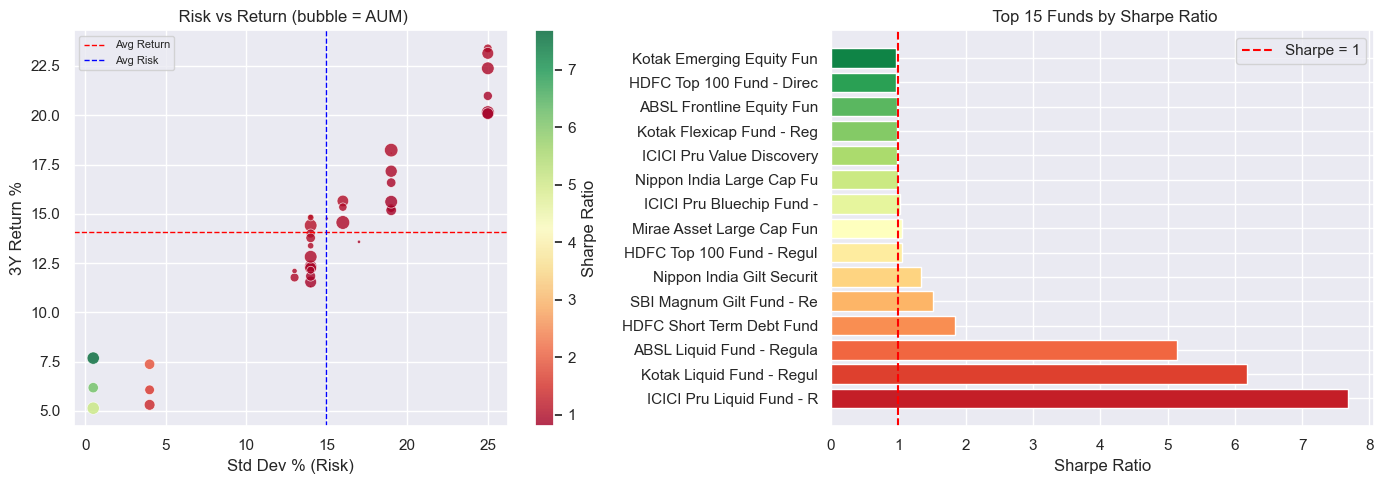

 Charts 11 & 12 saved — Risk vs Return


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 11 — Risk vs Return Scatter
scatter = axes[0].scatter(
    df_perf["std_dev_ann_pct"],
    df_perf["return_3yr_pct"],
    c=df_perf["sharpe_ratio"],
    s=df_perf["aum_crore"] / 500,
    cmap="RdYlGn", alpha=0.8,
    edgecolors="white", linewidths=0.5
)
plt.colorbar(scatter, ax=axes[0], label="Sharpe Ratio")
axes[0].set_title(" Risk vs Return (bubble = AUM)")
axes[0].set_xlabel("Std Dev % (Risk)")
axes[0].set_ylabel("3Y Return %")
axes[0].axhline(y=df_perf["return_3yr_pct"].mean(),
                color="red", linestyle="--", linewidth=1, label="Avg Return")
axes[0].axvline(x=df_perf["std_dev_ann_pct"].mean(),
                color="blue", linestyle="--", linewidth=1, label="Avg Risk")
axes[0].legend(fontsize=8)

# Chart 12 — Sharpe Ratio Bar
top = df_perf.nlargest(15, "sharpe_ratio")
axes[1].barh(top["scheme_name"].str[:25],
             top["sharpe_ratio"],
             color=sns.color_palette("RdYlGn", 15))
axes[1].set_title(" Top 15 Funds by Sharpe Ratio")
axes[1].set_xlabel("Sharpe Ratio")
axes[1].axvline(x=1.0, color="red", linestyle="--", label="Sharpe = 1")
axes[1].legend()

plt.tight_layout()
plt.savefig("bluestock/reports/charts/11_12_risk_return.png", dpi=150)
plt.show()
print(" Charts 11 & 12 saved — Risk vs Return")

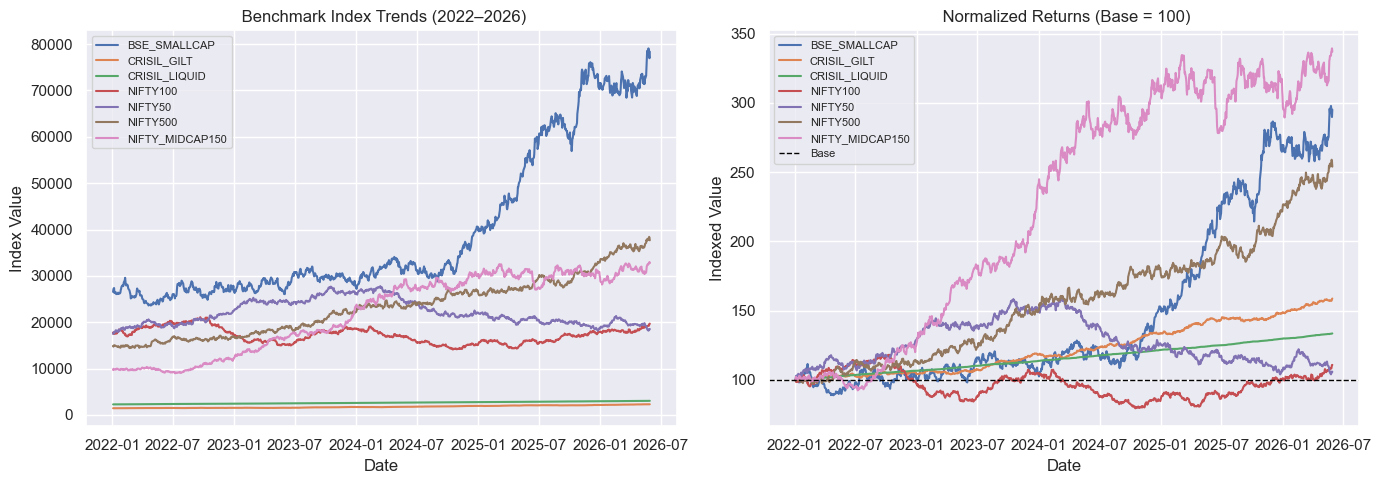

 Charts 13 & 14 saved — Benchmarks


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 13 — All Benchmarks Line
for name, grp in df_bm.groupby("index_name"):
    axes[0].plot(grp["date"], grp["close_value"],
                 label=name, linewidth=1.5)
axes[0].set_title(" Benchmark Index Trends (2022–2026)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index Value")
axes[0].legend(fontsize=8)

# Chart 14 — Normalized Returns (Base = 100)
for name, grp in df_bm.groupby("index_name"):
    grp = grp.sort_values("date")
    normalized = (grp["close_value"] / grp["close_value"].iloc[0]) * 100
    axes[1].plot(grp["date"], normalized, label=name, linewidth=1.5)
axes[1].set_title(" Normalized Returns (Base = 100)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Indexed Value")
axes[1].axhline(y=100, color="black",
                linestyle="--", linewidth=1, label="Base")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("bluestock/reports/charts/13_14_benchmarks.png", dpi=150)
plt.show()
print(" Charts 13 & 14 saved — Benchmarks")

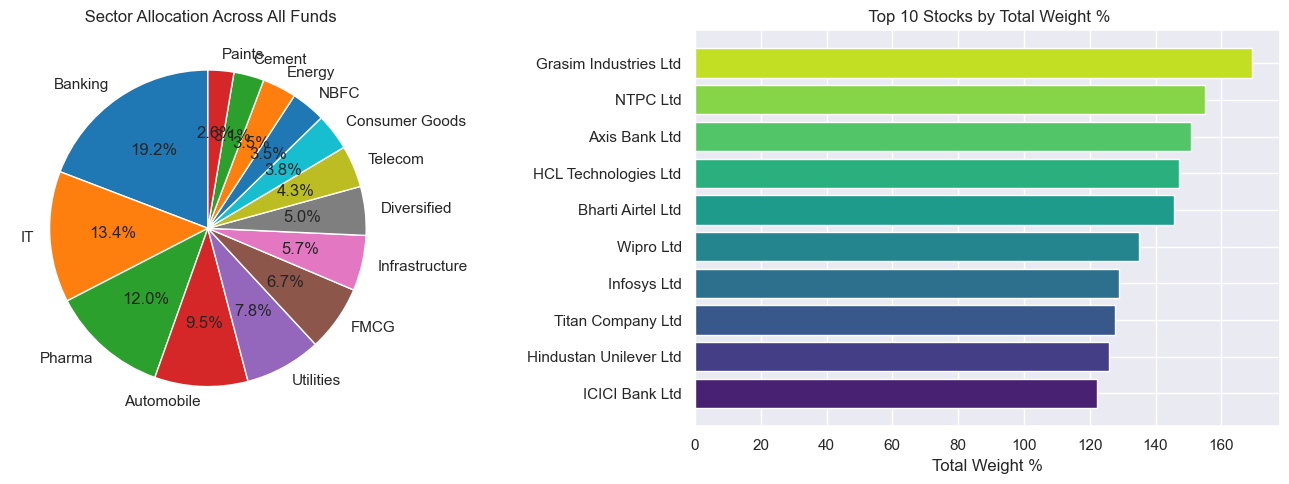

 Charts 15 & 16 saved — Sector & Holdings


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 15 — Sector Pie
sector_wt = df_hold.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
axes[0].pie(sector_wt, labels=sector_wt.index,
            autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("tab10", len(sector_wt)))
axes[0].set_title(" Sector Allocation Across All Funds")

# Chart 16 — Top 10 Stocks by Weight
top_stocks = df_hold.groupby("stock_name")["weight_pct"].sum()\
                    .nlargest(10).sort_values()
axes[1].barh(top_stocks.index, top_stocks.values,
             color=sns.color_palette("viridis", 10))
axes[1].set_title(" Top 10 Stocks by Total Weight %")
axes[1].set_xlabel("Total Weight %")

plt.tight_layout()
plt.savefig("bluestock/reports/charts/15_16_holdings.png", dpi=150)
plt.show()
print(" Charts 15 & 16 saved — Sector & Holdings")

In [17]:
print("="*60)
print(" KEY EDA FINDINGS — DAY 3")
print("="*60)

# 1. Best performing fund
best = df_perf.nlargest(1, "return_3yr_pct").iloc[0]
print(f"\n  Best 3Y Return : {best['scheme_name'][:40]}")
print(f"    Return        : {best['return_3yr_pct']}%")

# 2. Highest Sharpe
sharpe_best = df_perf.nlargest(1, "sharpe_ratio").iloc[0]
print(f"\n  Best Sharpe    : {sharpe_best['scheme_name'][:40]}")
print(f"    Sharpe Ratio  : {sharpe_best['sharpe_ratio']}")

# 3. SIP peak
sip_peak = df_sip.loc[df_sip["sip_inflow_crore"].idxmax()]
print(f"\n  SIP Peak       : ₹{sip_peak['sip_inflow_crore']:,} Cr")
print(f"    Month         : {sip_peak['month'].strftime('%b %Y')}")

# 4. AUM leader
aum_leader = df_aum.sort_values("date").groupby(
    "fund_house").last().nlargest(1, "aum_lakh_crore")
print(f"\n  AUM Leader     : {aum_leader.index[0]}")
print(f"    AUM           : ₹{aum_leader['aum_lakh_crore'].iloc[0]:.2f} Lakh Crore")

# 5. Folio growth
folio_start = df_fol["total_folios_crore"].iloc[0]
folio_end   = df_fol["total_folios_crore"].iloc[-1]
print(f"\n  Folio Growth   : {folio_start} Cr → {folio_end} Cr")
print(f"    Growth        : {((folio_end-folio_start)/folio_start*100):.1f}%")

# 6. Top state
top_state = df_txn.groupby("state")["amount_inr"].sum().idxmax()
print(f"\n  Top State      : {top_state}")

# 7. Dominant txn type
top_txn = df_txn["transaction_type"].value_counts().idxmax()
print(f"\n  Top Txn Type   : {top_txn} ({df_txn['transaction_type'].value_counts().iloc[0]:,} txns)")

# 8. Most popular sector
top_sector = df_hold.groupby("sector")["weight_pct"].sum().idxmax()
print(f"\n Top Sector     : {top_sector}")

# 9. Highest risk fund
riskiest = df_perf.nlargest(1,"std_dev_ann_pct").iloc[0]
print(f"\nHighest Risk   : {riskiest['scheme_name'][:40]}")
print(f"    Std Dev       : {riskiest['std_dev_ann_pct']}%")

# 10. Avg expense ratio
print(f"\n  Avg Expense    : {df_fund['expense_ratio_pct'].mean():.2f}%")
print(f"    Range         : {df_fund['expense_ratio_pct'].min()}% – {df_fund['expense_ratio_pct'].max()}%")

 KEY EDA FINDINGS — DAY 3

  Best 3Y Return : SBI Small Cap Fund - Regular Plan - Grow
    Return        : 23.39%

  Best Sharpe    : ICICI Pru Liquid Fund - Regular - Growth
    Sharpe Ratio  : 7.68

  SIP Peak       : ₹31,002 Cr
    Month         : Dec 2025

  AUM Leader     : SBI Mutual Fund
    AUM           : ₹12.50 Lakh Crore

  Folio Growth   : 13.26 Cr → 26.12 Cr
    Growth        : 97.0%

  Top State      : Punjab

  Top Txn Type   : Sip (19,716 txns)

 Top Sector     : Banking

Highest Risk   : SBI Small Cap Fund - Regular Plan - Grow
    Std Dev       : 25.0%

  Avg Expense    : 1.24%
    Range         : 0.55% – 1.64%


In [18]:
import subprocess

# Verify charts
charts = sorted(os.listdir("bluestock/reports/charts"))
print("="*50)
print(f" CHARTS SAVED ({len(charts)} files)")
print("="*50)
for c in charts:
    print(f"  {c}")

# Git commit
cmds = [
    ["git", "-C", "bluestock", "add", "."],
    ["git", "-C", "bluestock", "commit", "-m",
     "Day 3: EDA complete — 16 charts saved"],
    ["git", "-C", "bluestock", "push", "origin", "main"],
]
for cmd in cmds:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout or r.stderr)

 CHARTS SAVED (11 files)
  01_nav_trends.png
  02_aum_growth.png
  03_sip_inflows.png
  04_category_heatmap.png
  05_06_demographics.png
  07_08_geography.png
  09_folio_growth.png
  10_correlation_matrix.png
  11_12_risk_return.png
  13_14_benchmarks.png
  15_16_holdings.png

[main 54e76bc] Day 3: EDA complete â€” 16 charts saved
 11 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 reports/charts/01_nav_trends.png
 create mode 100644 reports/charts/02_aum_growth.png
 create mode 100644 reports/charts/03_sip_inflows.png
 create mode 100644 reports/charts/04_category_heatmap.png
 create mode 100644 reports/charts/05_06_demographics.png
 create mode 100644 reports/charts/07_08_geography.png
 create mode 100644 reports/charts/09_folio_growth.png
 create mode 100644 reports/charts/10_correlation_matrix.png
 create mode 100644 reports/charts/11_12_risk_return.png
 create mode 100644 reports/charts/13_14_benchmarks.png
 create mode 100644 reports/charts/15_16_holdings.png

